In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("quora_duplicate_questions.tsv", sep="\t")
print(df.shape)   # (404290, 6)
df.head()

(404290, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [2]:
new_df=df.sample(30000, random_state=42)

In [3]:
new_df 

,id,qid1,qid2,question1,question2,is_duplicate
8067,8067,15738,15739,How do I play Pokémon GO in Korea?,How do I play Pokémon GO in China?,0
368101,368101,12736,104117,What are some of the best side dishes for crab...,What are some good side dishes for buffalo chi...,0
70497,70497,121486,121487,Which is more advisable and better material fo...,What is the best server setup for buddypress?,0
226567,226567,254474,258192,How do I improve logical programming skills?,How can I improve my logical skills for progra...,1
73186,73186,48103,3062,How close we are to see 3rd world war?,How close is a World War III?,1
...,...,...,...,...,...,...
81275,81275,138027,138028,Who blocked me on Viber?,What can I do when someone blocked me on Viber?,0
273382,273382,6420,151321,Who are the most underrated actors and actress...,Who is Bollywood's most underrated actor?,1
142371,142371,12062,35905,How do I start learning c language?,How should I start to learn c language?,1
79120,79120,132716,134785,What is it like flying from Bangkok to Manila ...,What is it like flying from Bangkok to Manila ...,0


In [4]:
!pip install beautifulsoup4

In [5]:
from bs4 import BeautifulSoup
import re

def preprocess(q):
    q=str(q).lower().strip()
    
    q=q.replace("%"," percent ").replace("$"," dollar ").replace("₹"," rupee ").replace("€"," euro ").replace("£"," pound ").replace("¥"," yen ").replace("₩"," won ").replace("₽"," ruble ").replace("₺"," lira ").replace("₴"," hryvnia ").replace("₦"," naira ").replace("₵"," cedi ").replace("₸"," tenge ").replace("₼"," manat ").replace("₽"," ruble ").replace("₾"," lari ").replace("₿"," bitcoin ")
    q=q.replace('[math]','').replace('[/math]','')
    q=q.replace('000,000,000','b ').replace('000,000','m').replace('000','k')
    q=re.sub(r'([0-9]+)000000000',' \1b ',q)
    q=re.sub(r'([0-9]+)000000',' \1m ',q)
    q=re.sub(r'([0-9]+)000',' \1k ',q)
    
    CONTRACTIONS = {
    # AM
    "ain't":        "am not",
    "i'm":          "i am",

    # ARE
    "aren't":       "are not",
    "you're":       "you are",
    "we're":        "we are",
    "they're":      "they are",
    "who're":       "who are",
    "what're":      "what are",
    "there're":     "there are",

    # IS / HAS
    "isn't":        "is not",
    "he's":         "he is",
    "she's":        "she is",
    "it's":         "it is",
    "that's":       "that is",
    "what's":       "what is",
    "who's":        "who is",
    "where's":      "where is",
    "when's":       "when is",
    "why's":        "why is",
    "how's":        "how is",
    "here's":       "here is",
    "there's":      "there is",
    "this's":       "this is",

    # WAS / WERE
    "wasn't":       "was not",
    "weren't":      "were not",

    # HAVE
    "haven't":      "have not",
    "i've":         "i have",
    "you've":       "you have",
    "we've":        "we have",
    "they've":      "they have",
    "could've":     "could have",
    "should've":    "should have",
    "would've":     "would have",
    "might've":     "might have",
    "must've":      "must have",
    "who've":       "who have",

    # HAD / WOULD
    "hadn't":       "had not",
    "i'd":          "i would",
    "you'd":        "you would",
    "he'd":         "he would",
    "she'd":        "she would",
    "we'd":         "we would",
    "they'd":       "they would",
    "who'd":        "who would",
    "what'd":       "what did",
    "it'd":         "it would",

    # HAS
    "hasn't":       "has not",

    # WILL
    "won't":        "will not",
    "i'll":         "i will",
    "you'll":       "you will",
    "he'll":        "he will",
    "she'll":       "she will",
    "we'll":        "we will",
    "they'll":      "they will",
    "who'll":       "who will",
    "that'll":      "that will",
    "it'll":        "it will",

    # DO / DOES / DID
    "don't":        "do not",
    "doesn't":      "does not",
    "didn't":       "did not",

    # COULD / SHOULD / WOULD / MIGHT / MUST
    "couldn't":     "could not",
    "shouldn't":    "should not",
    "wouldn't":     "would not",
    "mightn't":     "might not",
    "mustn't":      "must not",
    "couldn't've":  "could not have",
    "shouldn't've": "should not have",
    "wouldn't've":  "would not have",

    # CAN
    "can't":        "cannot",
    "can't've":     "cannot have",

    # NEED / DARE
    "needn't":      "need not",
    "needn't've":   "need not have",
    "daren't":      "dare not",

    # MISC
    "'cause":       "because",
    "let's":        "let us",
    "ma'am":        "madam",
    "o'clock":      "of the clock",
    "o'er":         "over",
    "ne'er":        "never",
    "e'er":         "ever",
    "y'all":        "you all",
    "y'all'd":      "you all would",
    "y'all're":     "you all are",
    "y'all've":     "you all have",
    "not've":       "not have",
    "how'd":        "how did",
    "how'd'y":      "how do you",
    "how'll":       "how will",
    "i'd've":       "i would have",
    "it'd've":      "it would have",
    "she'd've":     "she would have",
    "he'd've":      "he would have",
    "we'd've":      "we would have",
    "they'd've":    "they would have",
    "when'd":       "when did",
    "where'd":      "where did",
    "why'd":        "why did",
    "who'd've":     "who would have",
    "that'd":       "that would",
    "that'd've":    "that would have",
    "there'd":      "there would",
    "there'd've":   "there would have",
    "here'd":       "here would",
    "how's":        "how is",
    "i'm":          "i am",
    "you've":       "you have",
    "we've":        "we have",
    "they've":      "they have",
    "who've":       "who have",
    "would've":     "would have",
    "should've":    "should have",
    "could've":     "could have",
    "must've":      "must have",    
    }
    
    q_dectracted=[]
    
    for word in q.split():
        if word in CONTRACTIONS:
            q_dectracted.append(CONTRACTIONS[word])
        else:
            q_dectracted.append(word)
            
    q=" ".join(q_dectracted)
    q=q.replace("'ve"," have").replace("'re"," are").replace("'ll"," will").replace("'d"," would").replace("'s"," is").replace("n't"," not")
    
    q=BeautifulSoup(q, "html.parser")
    q=q.get_text()
    
    pattern = re.compile(r'\W')
    q = re.sub(pattern, ' ', q).strip()
    

    return q
             

In [6]:
new_df["question1"]=new_df["question1"].apply(preprocess)
new_df["question2"]=new_df["question2"].apply(preprocess)

In [7]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1


In [8]:
new_df['len_q1']=new_df['question1'].str.len()
new_df['len_q2']=new_df['question2'].str.len()

In [9]:
new_df['q1_num_words']=new_df['question1'].apply(lambda x: len(x.split()))
new_df['q2_num_words']=new_df['question2'].apply(lambda x: len(x.split()))

In [10]:
def common_words(row):
    q1_words = set(map(lambda word: word.lower().strip(), row['question1'].split()))
    q2_words = set(map(lambda word: word.lower().strip(), row['question2'].split()))
    return len(q1_words.intersection(q2_words))

In [11]:
new_df['word_common']=new_df.apply(common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,7
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,6
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,95,44,16,8,2
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,6
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,4


In [12]:
def total_words(row):
    q1_words = set(map(lambda word: word.lower().strip(), row['question1'].split()))
    q2_words = set(map(lambda word: word.lower().strip(), row['question2'].split()))
    return len(q1_words.union(q2_words))

In [13]:
new_df['total_words']=new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,7,9
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,6,14
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,95,44,16,8,2,22
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,6,10
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,4,12


In [14]:
new_df['word_share']=round(new_df['word_common']/new_df['total_words'],2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words,word_share
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,7,9,0.78
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,6,14,0.43
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,95,44,16,8,2,22,0.09
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,6,10,0.60
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,4,12,0.33


minimum characters 0
maximum characters 336
average characters 58.611066666666666


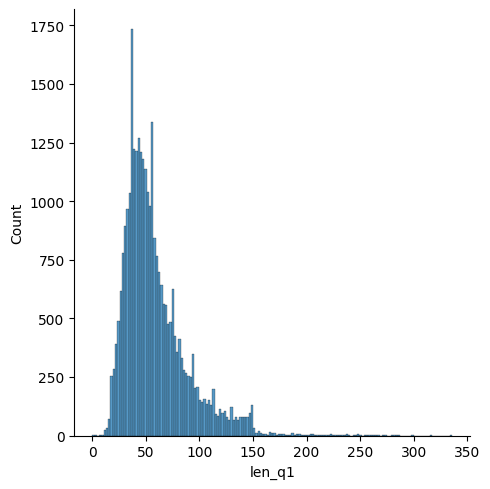

In [15]:
#analysis of features
sns.displot(new_df['len_q1'])
print('minimum characters',new_df['len_q1'].min())
print('maximum characters',new_df['len_q1'].max())
print('average characters',new_df['len_q1'].mean())

minimum characters 1
maximum characters 1170
average characters 58.7927


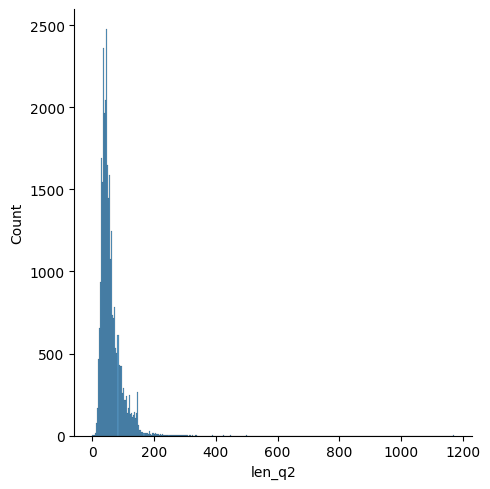

In [16]:
#analysis of features
sns.displot(new_df['len_q2'])
print('minimum characters',new_df['len_q2'].min())
print('maximum characters',new_df['len_q2'].max())
print('average characters',new_df['len_q2'].mean())

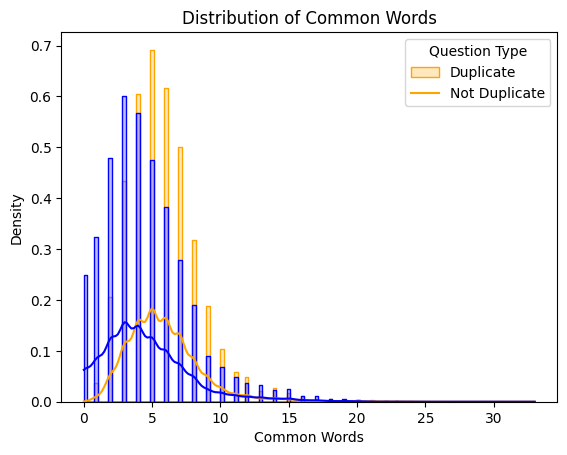

In [17]:
#common words
sns.histplot(
    data=new_df,
    x='word_common',
    hue='is_duplicate',
    kde=True,
    palette={0: 'blue', 1: 'orange'},
    element='step',
    stat='density',
    common_norm=False
)

plt.legend(title='Question Type', labels=['Duplicate', 'Not Duplicate'])
plt.xlabel('Common Words')
plt.ylabel('Density')
plt.title('Distribution of Common Words')
plt.show()

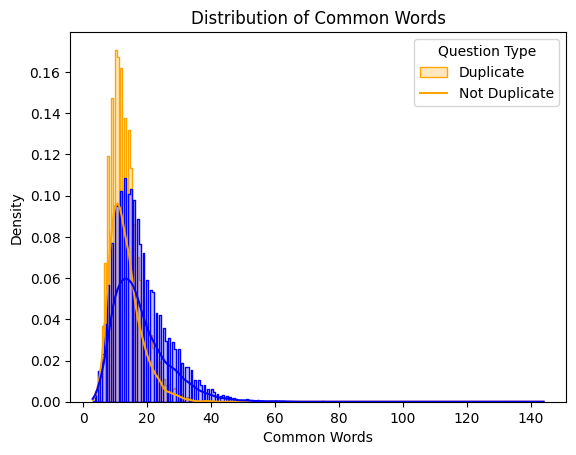

In [18]:
#total words
sns.histplot(
    data=new_df,
    x='total_words',
    hue='is_duplicate',
    kde=True,
    palette={0: 'blue', 1: 'orange'},
    element='step',
    stat='density',
    common_norm=False
)

plt.legend(title='Question Type', labels=['Duplicate', 'Not Duplicate'])
plt.xlabel('Common Words')
plt.ylabel('Density')
plt.title('Distribution of Common Words')
plt.show()

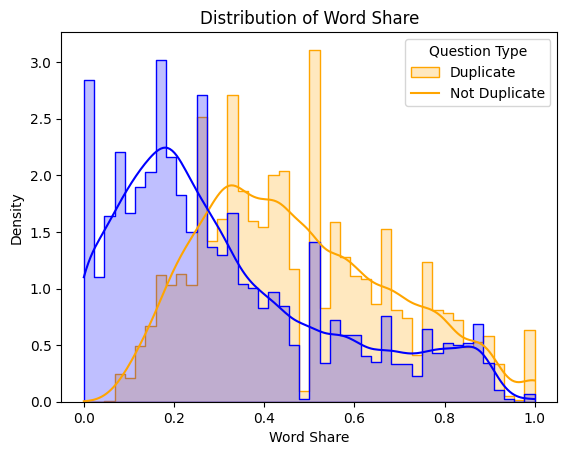

In [19]:
#total words
sns.histplot(
    data=new_df,
    x='word_share',
    hue='is_duplicate',
    kde=True,
    palette={0: 'blue', 1: 'orange'},
    element='step',
    stat='density',
    common_norm=False
)

plt.legend(title='Question Type', labels=['Duplicate', 'Not Duplicate'])
plt.xlabel('Word Share')
plt.ylabel('Density')
plt.title('Distribution of Word Share')
plt.show()

In [20]:
#advance feature engineering
from nltk.corpus import stopwords

def fetch_token_features(row):
    
    q1=row['question1']
    q2=row['question2']
    
    SAFE_DIV = 0.0001
    
    STOP_WORDS = set(stopwords.words("english"))
    
    token_features = [0.0] * 8
    
    #converting into tokens
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features
    
    #Non-stopwords
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #stopwords
    q1_stopwords = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stopwords = set([word for word in q2_tokens if word in STOP_WORDS])
    
    common_word_count = len(q1_words.intersection(q2_words))
    common_stop_count = len(q1_stopwords.intersection(q2_stopwords))
    
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stopwords), len(q2_stopwords)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stopwords), len(q2_stopwords)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [21]:
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"] = list(map(lambda x: x[0], token_features))
new_df["cwc_max"] = list(map(lambda x: x[1], token_features))
new_df["csc_min"] = list(map(lambda x: x[2], token_features))
new_df["csc_max"] = list(map(lambda x: x[3], token_features))
new_df["ctc_min"] = list(map(lambda x: x[4], token_features))
new_df["ctc_max"] = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"] = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [22]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,...,total_words,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,9,0.78,0.749981,0.749981,0.999975,0.999975,0.874989,0.874989,0.0,1.0
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,14,0.43,0.399992,0.399992,0.999975,0.666656,0.666659,0.545450,0.0,1.0
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,95,44,16,8,...,22,0.09,0.000000,0.000000,0.499988,0.249997,0.249997,0.124999,0.0,0.0
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,10,0.60,0.999975,0.999975,0.666644,0.399992,0.857131,0.666659,0.0,1.0
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,12,0.33,0.749981,0.599988,0.333322,0.249994,0.571420,0.444440,0.0,1.0


In [23]:
import sys
!{sys.executable} -m pip install distance

In [24]:
import sys
!{sys.executable} -m pip install textdistance

In [25]:
import textdistance
def fetch_length_features(row):
    
    q1=row['question1']
    q2=row['question2']
    length_features = [0.0] * 3
    
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    length_features[1] = len(q1_tokens) + (len(q2_tokens))/2
    
    lcs = textdistance.lcsstr(q1, q2)
    length_features[2] = len(lcs) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [26]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df["len2_q1"] = list(map(lambda x: x[0], length_features))
new_df["len2_q2"] = list(map(lambda x: x[1], length_features))
new_df["len2_ratio"] = list(map(lambda x: x[2], length_features))

In [27]:
import sys
!{sys.executable} -m pip install fuzzywuzzy

In [28]:
#Fuzzy features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    q1=row['question1']
    q2=row['question2']
    
    fuzzy_features=[0.0] * 4
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)
    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)
    # fuzz_token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)
    # fuzz_token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)
    
    return fuzzy_features

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [29]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

#Creating new columns for fuzzy features
new_df["fuzz_ratio"]=list(map(lambda x: x[0], fuzzy_features))
new_df["fuzz_partial_ratio"]=list(map(lambda x: x[1], fuzzy_features))
new_df["fuzz_token_sort_ratio"]=list(map(lambda x: x[2], fuzzy_features))
new_df["fuzz_token_set_ratio"]=list(map(lambda x: x[3], fuzzy_features))

In [30]:
print(new_df.shape)
new_df.head()

(30000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,len2_q1,len2_q2,len2_ratio,fuzz_ratio,fuzz_partial_ratio,fuzz_token_sort_ratio,fuzz_token_set_ratio
8067,8067,15738,15739,how do i play pokémon go in korea,how do i play pokémon go in china,0,33,33,8,8,...,0.874989,0.0,1.0,0.0,12.0,0.823529,88,88,81,90
368101,368101,12736,104117,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...,0,52,50,11,9,...,0.545450,0.0,1.0,2.0,15.5,0.333333,73,72,73,73
70497,70497,121486,121487,which is more advisable and better material fo...,what is the best server setup for buddypress,0,95,44,16,8,...,0.124999,0.0,0.0,8.0,20.0,0.111111,35,43,36,24
226567,226567,254474,258192,how do i improve logical programming skills,how can i improve my logical skills for progra...,1,43,51,7,9,...,0.666659,0.0,1.0,2.0,11.5,0.272727,72,67,89,96
73186,73186,48103,3062,how close we are to see 3rd world war,how close is a world war iii,1,37,28,9,7,...,0.444440,0.0,1.0,2.0,12.5,0.344828,68,61,71,81


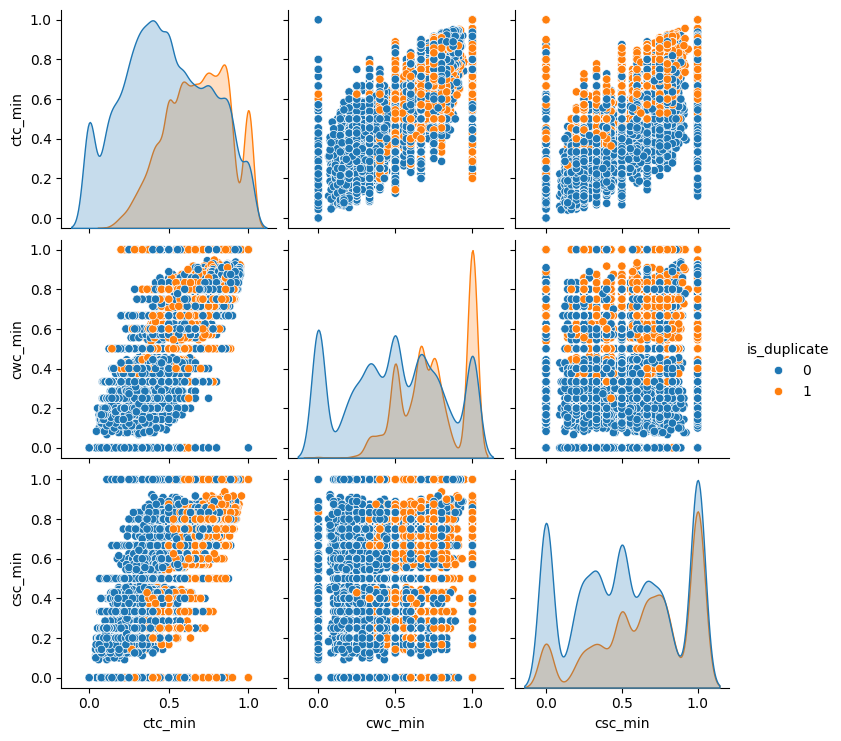

In [31]:
sns.pairplot(new_df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']], hue='is_duplicate')

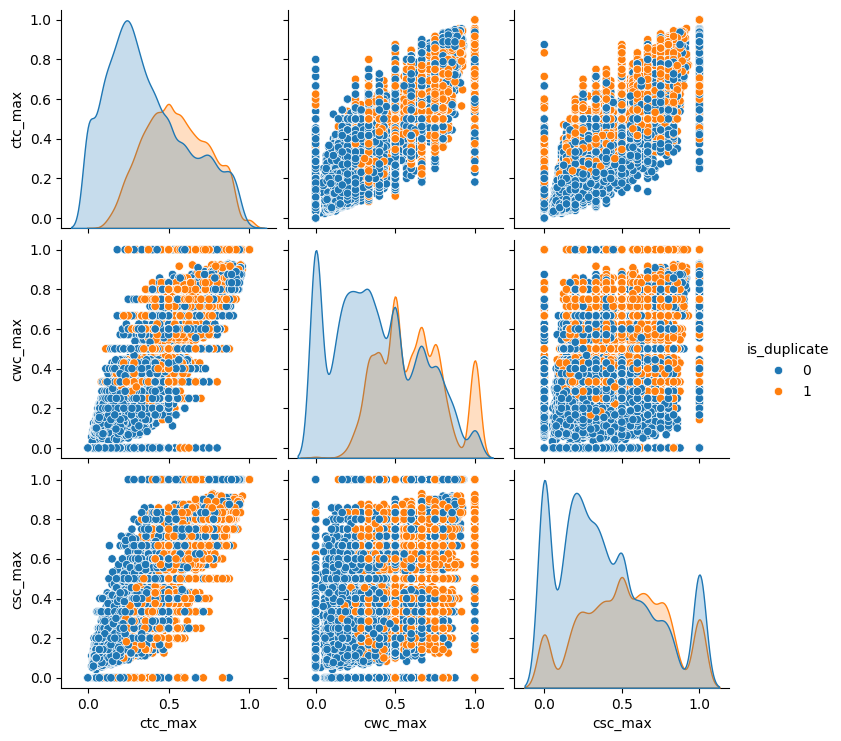

In [32]:
sns.pairplot(new_df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']], hue='is_duplicate')

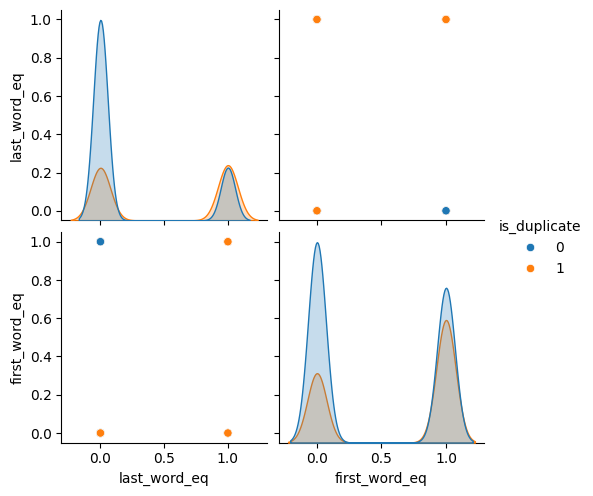

In [33]:
sns.pairplot(new_df[['last_word_eq', 'first_word_eq', 'is_duplicate']], hue='is_duplicate')

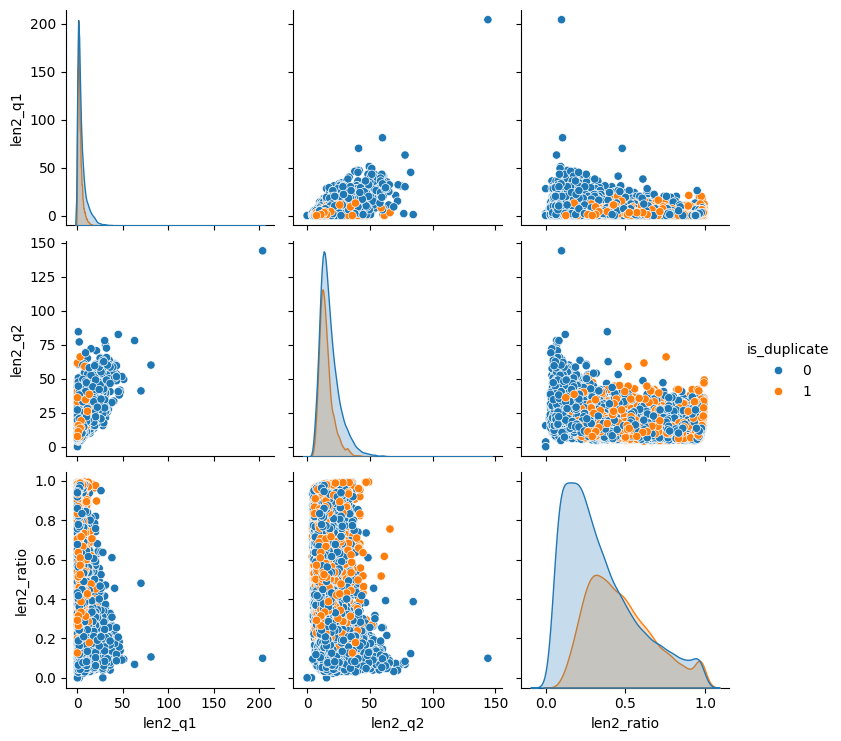

In [34]:
sns.pairplot(new_df[['len2_q1', 'len2_q2', 'len2_ratio', 'is_duplicate']], hue='is_duplicate')

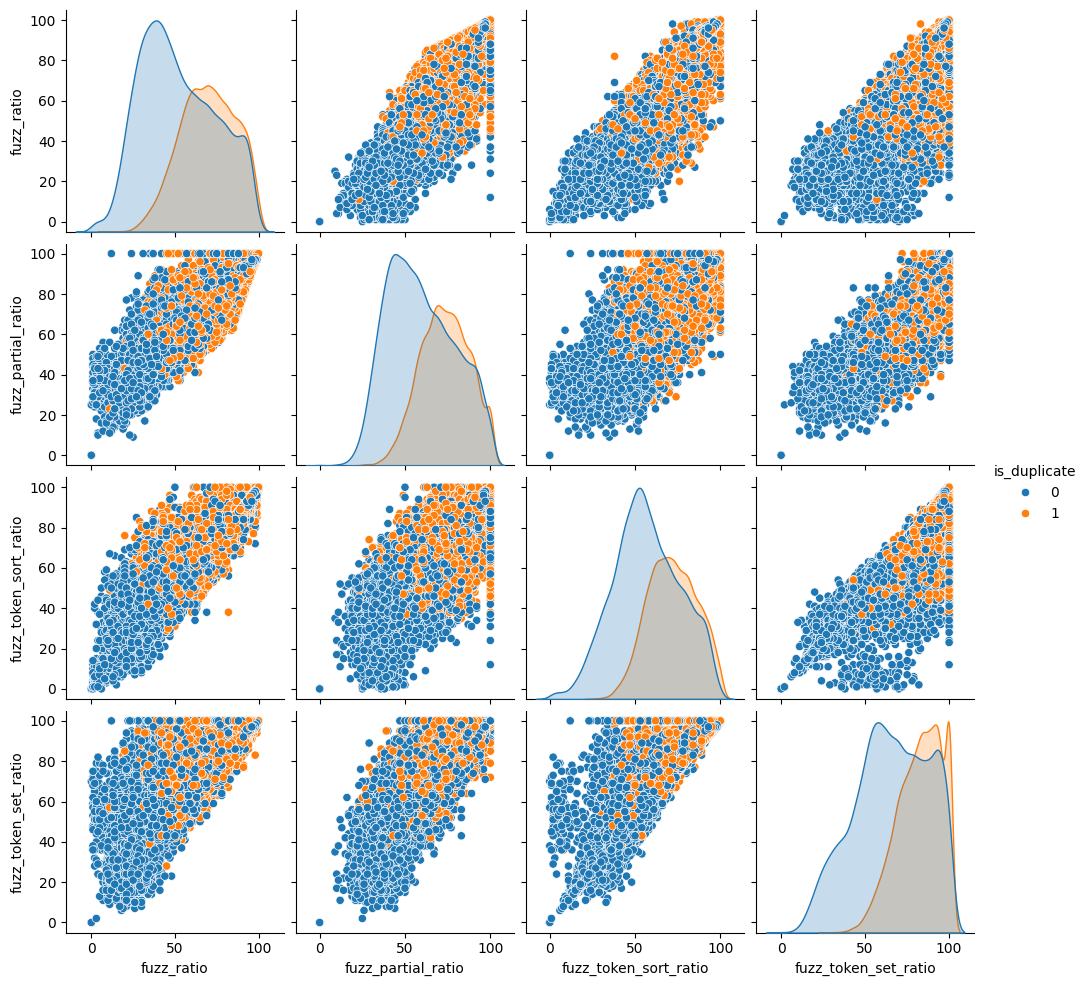

In [35]:
sns.pairplot(new_df[['fuzz_ratio', 'fuzz_partial_ratio', 'fuzz_token_sort_ratio', 'fuzz_token_set_ratio', 'is_duplicate']], hue='is_duplicate')

In [36]:
from sklearn.preprocessing import MinMaxScaler

x=MinMaxScaler().fit_transform(new_df[['ctc_min', 'cwc_min', 'csc_min', 'ctc_max', 'cwc_max', 'csc_max', 'last_word_eq', 'first_word_eq', 'len2_q1', 'len2_q2', 'len2_ratio', 'fuzz_ratio', 'fuzz_partial_ratio', 'fuzz_token_sort_ratio', 'fuzz_token_set_ratio']])

In [37]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    init='random',
    method='barnes_hut',
    max_iter=1000,
    verbose=2,
    angle=0.5,
    random_state=101
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.072s...
[t-SNE] Computed neighbors for 30000 samples in 4.273s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

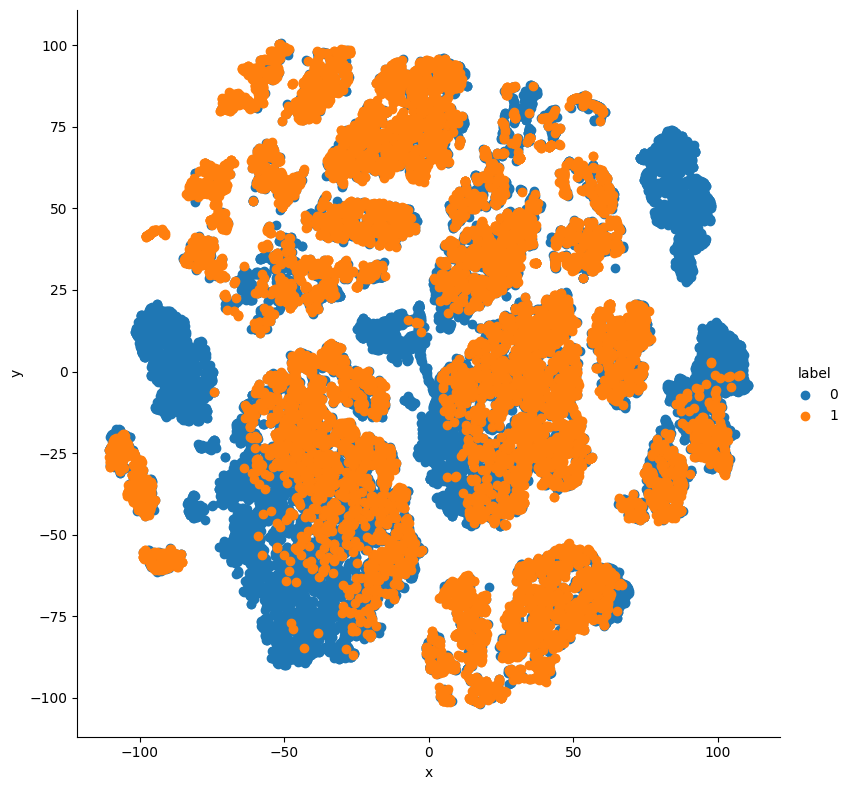

In [38]:
tsne_df = pd.DataFrame()
tsne_df['x'] = tsne[:, 0]
tsne_df['y'] = tsne[:, 1]
tsne_df['label'] = new_df['is_duplicate'].values

sns.FacetGrid(tsne_df, hue='label', height=8).map(
    plt.scatter,
    'x',
    'y'
).add_legend()

plt.show()

In [39]:
tsne_3d = TSNE(
    n_components=3,
    init='random',
    method='barnes_hut',
    max_iter=1000,
    verbose=2,
    angle=0.5,
    random_state=101
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.061s...
[t-SNE] Computed neighbors for 30000 samples in 4.607s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [40]:
tsne_3d_df = pd.DataFrame()
tsne_3d_df['x'] = tsne_3d[:, 0]
tsne_3d_df['y'] = tsne_3d[:, 1]
tsne_3d_df['z'] = tsne_3d[:, 2]
tsne_3d_df['label'] = new_df['is_duplicate'].values

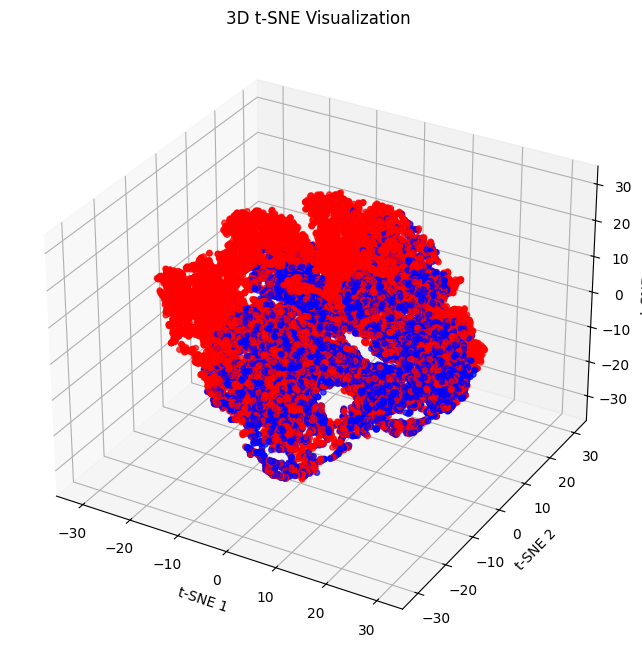

In [41]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = tsne_3d_df['label'].map({0: 'red', 1: 'blue'})

ax.scatter(
    tsne_3d_df['x'],
    tsne_3d_df['y'],
    tsne_3d_df['z'],
    c=colors,
    s=15,
    alpha=0.7
)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('3D t-SNE Visualization')

plt.show()

In [42]:
ques_df=new_df[['question1', 'question2']]
ques_df.head()

,question1,question2
8067,how do i play pokémon go in korea,how do i play pokémon go in china
368101,what are some of the best side dishes for crab...,what are some good side dishes for buffalo chi...
70497,which is more advisable and better material fo...,what is the best server setup for buddypress
226567,how do i improve logical programming skills,how can i improve my logical skills for progra...
73186,how close we are to see 3rd world war,how close is a world war iii


In [43]:
final_df=new_df.drop(columns=['id','qid1','qid2','question1', 'question2'])
print(final_df.shape)
final_df.head()

(30000, 23)


,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,len2_q1,len2_q2,len2_ratio,fuzz_ratio,fuzz_partial_ratio,fuzz_token_sort_ratio,fuzz_token_set_ratio
8067,0,33,33,8,8,7,9,0.78,0.749981,0.749981,...,0.874989,0.0,1.0,0.0,12.0,0.823529,88,88,81,90
368101,0,52,50,11,9,6,14,0.43,0.399992,0.399992,...,0.545450,0.0,1.0,2.0,15.5,0.333333,73,72,73,73
70497,0,95,44,16,8,2,22,0.09,0.000000,0.000000,...,0.124999,0.0,0.0,8.0,20.0,0.111111,35,43,36,24
226567,1,43,51,7,9,6,10,0.60,0.999975,0.999975,...,0.666659,0.0,1.0,2.0,11.5,0.272727,72,67,89,96
73186,1,37,28,9,7,4,12,0.33,0.749981,0.599988,...,0.444440,0.0,1.0,2.0,12.5,0.344828,68,61,71,81


In [44]:
from sklearn.feature_extraction.text import CountVectorizer
questions = ques_df['question1'].tolist() + ques_df['question2'].tolist()
cv = CountVectorizer(max_features=3000)
q1_arr,q2_arr = np.vsplit(cv.fit_transform(questions).toarray(),2)
print(q1_arr.shape)

(30000, 3000)


In [45]:
temp_df1=pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2=pd.DataFrame(q2_arr, index=ques_df.index)
temp_df=pd.concat([temp_df1,temp_df2], axis=1)
temp_df.shape

(30000, 6000)

In [46]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
368101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
70497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
226567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73186,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81275,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
273382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
142371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
79120,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [47]:
final_df=pd.concat([final_df,temp_df], axis=1)
print(final_df.shape)
final_df.head()

(30000, 6023)


,is_duplicate,len_q1,len_q2,q1_num_words,q2_num_words,word_common,total_words,word_share,cwc_min,cwc_max,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
8067,0,33,33,8,8,7,9,0.78,0.749981,0.749981,...,0,0,0,0,0,0,0,0,0,0
368101,0,52,50,11,9,6,14,0.43,0.399992,0.399992,...,0,0,0,0,0,0,0,0,0,0
70497,0,95,44,16,8,2,22,0.09,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
226567,1,43,51,7,9,6,10,0.60,0.999975,0.999975,...,0,0,0,0,0,0,0,0,0,0
73186,1,37,28,9,7,4,12,0.33,0.749981,0.599988,...,0,0,0,0,0,0,0,0,0,0


In [48]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(final_df.iloc[:, 1:].values, final_df.iloc[:, 0].values, test_size=0.2, random_state=42)

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8038333333333333


In [50]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train,y_train)
y_pred_xgb = xgb.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.7941666666666667


In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
confusion_matrix(y_test, y_pred)

array([[3312,  523],
       [ 654, 1511]])

In [53]:
confusion_matrix(y_test, y_pred_xgb)

array([[3222,  613],
       [ 622, 1543]])

In [54]:
SAFE_DIV = 0.0001

def common_words(q1, q2):
    q1_words = set(map(lambda word: word.lower().strip(), q1.split()))
    q2_words = set(map(lambda word: word.lower().strip(), q2.split()))
    return len(q1_words.intersection(q2_words))


def total_words(q1, q2):
    q1_words = set(map(lambda word: word.lower().strip(), q1.split()))
    q2_words = set(map(lambda word: word.lower().strip(), q2.split()))
    return len(q1_words.union(q2_words))


def fetch_token_features(q1, q2):
    token_features = [0.0] * 8

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    q1_words = set([word for word in q1_tokens])
    q2_words = set([word for word in q2_tokens])

    common_word_count = len(q1_words.intersection(q2_words))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)

    token_features[2] = common_word_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[3] = common_word_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    token_features[4] = int(q1_tokens[-1] == q2_tokens[-1])
    token_features[5] = int(q1_tokens[0] == q2_tokens[0])

    token_features[6] = abs(len(q1_tokens) - len(q2_tokens))
    token_features[7] = (len(q1_tokens) + len(q2_tokens)) / 2

    return token_features


def fetch_length_features(q1, q2):
    length_features = [0.0] * 3

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    lcs = textdistance.lcsstr(q1, q2)
    length_features[2] = len(lcs) / (min(len(q1), len(q2)) + 1)

    return length_features


def fetch_fuzzy_features(q1, q2):
    fuzzy_features = [0.0] * 4

    fuzzy_features[0] = fuzz.QRatio(q1, q2)
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [55]:
def query_point_creator(q1,q2):
    
    input_query = []
    
    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)
    
    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))
    
    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))
    
    input_query.append(common_words(q1,q2))
    input_query.append(total_words(q1,q2))
    input_query.append(round(common_words(q1,q2)/total_words(q1,q2),2))
    
    # fetch token features
    token_features = fetch_token_features(q1,q2)
    input_query.extend(token_features)
    
    # fetch length based features
    length_features = fetch_length_features(q1,q2)
    input_query.extend(length_features)
    
    # fetch fuzzy features
    fuzzy_features = fetch_fuzzy_features(q1,q2)
    input_query.extend(fuzzy_features)
    
    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()
    
    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()
    
    return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [56]:
q1="What is the capital of India?"
q2="What is the current capital of India?"

In [57]:
rf.predict(query_point_creator(q1,q2))

array([1])